# Analiza napadalnih igralcev lige NFL v rednem delu sezone 2025/26

Analizirali bomo podatke o NFL igralcih iz sezone 2025/26, pridobljene s portala [Pro-Football-Reference](https://www.pro-football-reference.com). Zajeti so podatki o podajah (Passing), tekih (Rushing), ujetih podajah (Receiving) in obrambi (Defense).

#### Priprava podatkov

Najprej uvozimo vse potrebne knjižnice ter pripravimo podatke za analizo. Številske stolpce pretvorimo v ustrezne tipe in ustvarimo dodatne metrike za analizo učinkovitosti igralcev.

In [37]:
import pandas as pd
import matplotlib.pyplot as plt

# Nastavitev za lepši izris grafov
%matplotlib inline

# Naložimo CSV datoteko
df = pd.read_csv("podatki/nfl_2025_statistika.csv")

st_vrstic = len(df)
st_stolpcev = len(df.columns)

print(f"Spodaj lahko vidimo tabelo NFL igralcev z vsemi stolpci, ki jih bomo uporabljali. Imamo tabelo {st_vrstic} igralcev z {st_stolpcev} stolpci: med njimi so ime igralca, ekipa, pozicija, starost, odigrane tekme ter zbrane statistike po kategorijah.")

display(df)

Spodaj lahko vidimo tabelo NFL igralcev z vsemi stolpci, ki jih bomo uporabljali. Imamo tabelo 1764 igralcev z 21 stolpci: med njimi so ime igralca, ekipa, pozicija, starost, odigrane tekme ter zbrane statistike po kategorijah.


,igralec,ekipa,pozicija,starost,tekme,passing_yards,passing_td,passing_att,passing_cmp,passing_int,...,rushing_yards,rushing_td,rushing_att,fumbles,receiving_yards,receiving_td,receptions,targets,def_interceptions,def_sacks
0,A'Shawn Robinson,CAR,DT,30,17,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,A.J. Brown,PHI,WR,28,15,0,0,0,0,0,...,0,0,0,0,1028,7,81,128,0,0
2,A.J. Epenesa,BUF,DE,27,16,0,0,0,0,0,...,0,0,0,0,0,0,0,0,2,0
3,A.J. Green,MIA,CB,27,3,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,AJ Barner,SEA,TE,23,17,0,0,0,0,0,...,16,1,11,6,586,7,58,75,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1759,Zeek Biggers,MIA,DT,22,9,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1760,Zion Childress,DAL,CB,23,3,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1761,Zion Logue,BUF,DT,24,3,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1762,Zonovan Knight,ARI,RB,24,12,0,0,0,0,0,...,269,4,82,2,160,1,22,31,0,0


#### Pregled najboljših igralcev

Spodaj je prikazana tabela 10 najučinkovitejših igralcev lige glede na skupno število pridobljenih jardov (podaje + teki + sprejemi) v sezoni. Tabela vključuje tudi podrobnejše podatke pridobljenih jardov po posameznih kategorijah ter skupno število doseženih touchdownov (`total_td`). Pričakovano so vsi igralci podajalci (quarterbacki), razumljivo pa je nizko oziroma ničelno število jardov po sprejemu (receiving yards), saj je to naloga sprejemalcev (receivers) in podajalci priložnosti za lovljenje nimajo razen ob "trick plays", ko žogo meče nekdo, ki ni podajalec in napadalna ekipa želi zmesti obrambno.

In [51]:
import pandas as pd

# Naložimo podatke
df = pd.read_csv("podatki/nfl_2025_statistika.csv")

# Izračunamo skupne jarde in TD-je, če še niso izračunani
df["skupni_jardi"] = df.get("passing_yards", 0) + df.get("rushing_yards", 0) + df.get("receiving_yards", 0)
df["skupni_td"] = df.get("passing_td", 0) + df.get("rushing_td", 0) + df.get("receiving_td", 0)

# Pretvorimo vse številske stolpce v cela števila (brez .0)
for col in df.select_dtypes(include=["float64", "int64"]).columns:
    df[col] = df[col].fillna(0).astype(int)

# Pripravimo top 10
top_10_vsi = df.sort_values(by="skupni_jardi", ascending=False).head(10).copy()
top_10_vsi = top_10_vsi.reset_index(drop=True)
top_10_vsi.index = top_10_vsi.index + 1

# Prikaz tabele v Jupyter Notebooku
top_10_vsi[["igralec", "ekipa", "pozicija", "tekme", "passing_yards", "rushing_yards", "receiving_yards", "skupni_jardi", "skupni_td"]]

,igralec,ekipa,pozicija,tekme,passing_yards,rushing_yards,receiving_yards,skupni_jardi,skupni_td
1,Drake Maye,NWE,QB,17,4394,450,2,4846,35
2,Dak Prescott,DAL,QB,17,4552,177,0,4729,32
3,Matthew Stafford,LAR,QB,17,4707,1,0,4708,46
4,Jared Goff,DET,QB,17,4564,45,0,4609,34
5,Trevor Lawrence,JAX,QB,17,4007,359,0,4366,38
6,Caleb Williams,CHI,QB,17,3942,388,22,4352,31
7,Bo Nix,DEN,QB,17,3931,356,0,4287,30
8,Josh Allen,BUF,QB,17,3668,579,0,4247,39
9,Justin Herbert,LAC,QB,16,3727,498,0,4225,28
10,Sam Darnold,SEA,QB,17,4048,95,0,4143,25


Vidimo, da se nekateri podajalci, kot sta Josh Allen in Drake Maye večkrat odločijo za tek, medtem, ko se denimo Matthew Stafford za tek ne odloči skoraj nikoli. 

## 1. Analiza podajalcev (quarterback)

#### Najboljša razmerja med touchdowni (TD) in prestreženimi podajami (INT)

Spodnji graf prikazuje podajalce, ki so dosegli vsaj 10 touchdownov in zbrali vsaj 1500 jardov s podajo, razvrščeni glede na učinkovitost (razmereje med TD in INT)

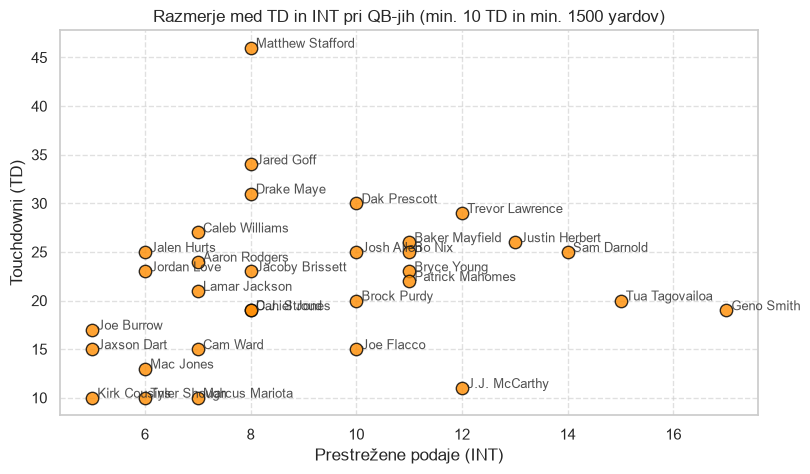

In [62]:
# Pripravimo podatke z dodatnim pogojem za vsaj 1500 passing yardov
qb_graf_df = df[(df["pozicija"] == "QB") & (df["passing_td"] >= 10) & (df["passing_yards"] >= 1500)].copy()

plt.figure(figsize=(9, 5))
plt.scatter(qb_graf_df["passing_int"], qb_graf_df["passing_td"], color="darkorange", s=80, edgecolors="black", alpha=0.8)

plt.title("Razmerje med TD in INT pri QB-jih (min. 10 TD in min. 1500 yardov)")
plt.xlabel("Prestrežene podaje (INT)")
plt.ylabel("Touchdowni (TD)")
plt.grid(True, linestyle="--", alpha=0.6)

# Dodamo imena igralcev zraven njihovih točk
for i, row in qb_graf_df.iterrows():
    plt.annotate(row["igralec"], (row["passing_int"] + 0.1, row["passing_td"]), fontsize=9, alpha=0.8)

plt.show()

Na grafu izstopa Matthew Stafford, ki je bil razglašen za najboljšega igralca sezone (MVP). Pod njim sta dva neposredna konkurenta za to nagrado, Jared Goff in Drake Maye. Svojih ekip pa nista navdušila Geno Smith in Tua Tagovailoa, saj sta imela skoraj več prestreženih podaj kot touchdownov.

#### Primerjava globokih podaj (Y/A) in natančnosti (Cmp%)
Spodnja tabela primerja povprečne osvojene jarde na poskus podaje (Y/A) z odstotkom točnih podaj za podajalce z vsaj 150 poskusi podaj.

In [69]:
# Izračunamo jarde na podajo in odstotek točnih podaj
qb_df["jardi_na_podajo"] = qb_df["passing_yards"] / qb_df["passing_att"].replace(0, 1)
qb_df["procent_točnih"] = (qb_df["passing_cmp"] / qb_df["passing_att"].replace(0, 1)) * 100

# Filtriramo, sortiramo po jardih na podajo in vzamemo top 10
rezultat_ya = qb_df[qb_df["passing_att"] > 150].sort_values(by="jardi_na_podajo", ascending=False).head(10).copy()

# Ponastavimo indeks od 1 do 10
rezultat_ya = rezultat_ya.reset_index(drop=True)
rezultat_ya.index = rezultat_ya.index + 1


rezultat_ya[["igralec", "ekipa", "procent_točnih", "jardi_na_podajo", "passing_yards"]]

,igralec,ekipa,procent_točnih,jardi_na_podajo,passing_yards
1,Drake Maye,NWE,71.951220,8.930894,4394
2,Sam Darnold,SEA,67.714885,8.486373,4048
3,Lamar Jackson,BAL,63.576159,8.440397,2549
4,Daniel Jones,IND,67.968750,8.075521,3101
5,Josh Allen,BUF,69.347826,7.973913,3668
6,Jared Goff,DET,67.993080,7.896194,4564
7,Matthew Stafford,LAR,64.991625,7.884422,4707
8,Jordan Love,GNB,66.287016,7.701595,3381
9,Brock Purdy,SFO,69.366197,7.630282,2167
10,Dak Prescott,DAL,67.333333,7.586667,4552


## 2. Analiza tekačev (running back)

#### Igralci, ki so pridobili največ jardov s tekom
V tabeli vidimo igralce, ki so svoji ekipi prinesli najvec jardov s tekom z žogo.

In [70]:
# Izberemo absolutnih top 10 tekačev (RB) po skupnih tekaških jardih ne glede na prag poskusov
top_10_rb_skupaj = df[df["pozicija"] == "RB"].sort_values(by="rushing_yards", ascending=False).head(10).copy()

# Ponastavimo indeks od 1 do 10
top_10_rb_skupaj = top_10_rb_skupaj.reset_index(drop=True)
top_10_rb_skupaj.index = top_10_rb_skupaj.index + 1


top_10_rb_skupaj[["igralec", "ekipa", "rushing_att", "rushing_yards", "rushing_td"]]

,igralec,ekipa,rushing_att,rushing_yards,rushing_td
1,James Cook,BUF,309,1621,12
2,Derrick Henry,BAL,307,1595,16
3,Jonathan Taylor,IND,323,1585,18
4,Bijan Robinson,ATL,287,1478,7
5,De'Von Achane,MIA,238,1350,8
6,Kyren Williams,LAR,259,1252,10
7,Jahmyr Gibbs,DET,243,1223,13
8,Christian McCaffrey,SFO,311,1202,10
9,Javonte Williams,DAL,252,1201,11
10,Saquon Barkley,PHI,280,1140,7


Primarna naloga tekačev je pridobitev jardov s tekom (rushing yards). Največ jih je svoji ekipi prinesel James Cook, ne daleč za njim pa sta Derrick Henry in Jonathan Taylor, vsi trije spadajo med najboljše tekače v ligi.

#### Učinkovitost ali le velika obremenitev?
Poglejmo primerjavo med tem koliko jardov so igralci pridobili na vsak tek in med njihovimi skupnimi jardi, torej učinkovitost igralca ob vsakem poskusu.


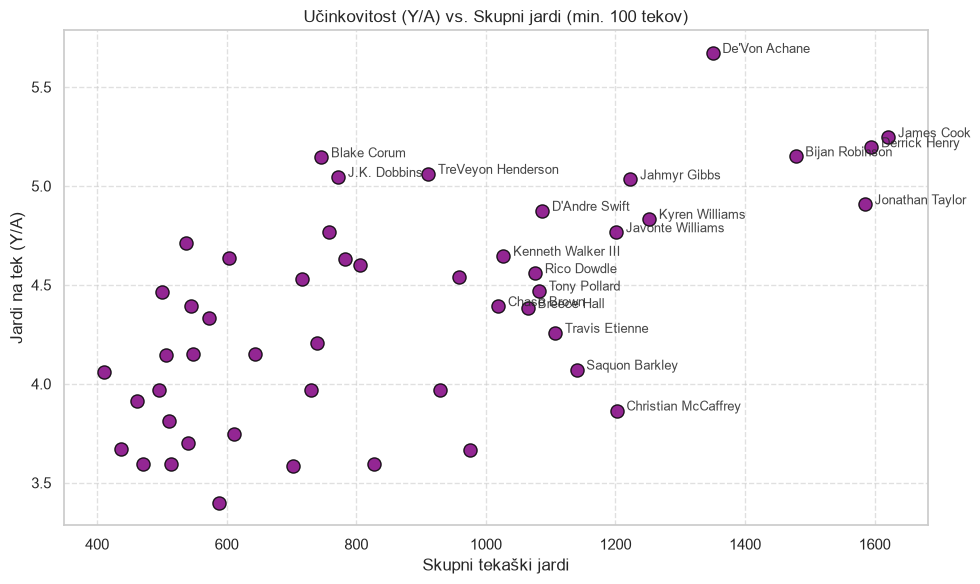

In [71]:
rb_analiza = df[(df["pozicija"] == "RB") & (df["rushing_att"] >= 100)].copy()
rb_analiza["jardi_na_tek"] = rb_analiza["rushing_yards"] / rb_analiza["rushing_att"]

plt.figure(figsize=(10, 6))
# Popravljeno iz edgecoordinates v edgecolors
plt.scatter(rb_analiza["rushing_yards"], rb_analiza["jardi_na_tek"], color="purple", s=90, edgecolors="black", alpha=0.85)

plt.title("Učinkovitost (Y/A) vs. Skupni jardi (min. 100 tekov)")
plt.xlabel("Skupni tekaški jardi")
plt.ylabel("Jardi na tek (Y/A)")
plt.grid(True, linestyle="--", alpha=0.6)

for i, row in rb_analiza.iterrows():
    if row["rushing_yards"] > 1000 or row["jardi_na_tek"] > 5.0:
        plt.annotate(row["igralec"], (row["rushing_yards"] + 15, row["jardi_na_tek"]), fontsize=9, alpha=0.85)

plt.tight_layout()
plt.show()

Pričakovano so najboljši tekači v ligi zelo učinkoviti in zelo obremenjeni. Največ jardov na tek je pridobil De'Von Achane, malo več kot 5,5.

#### Učinkovitost tekačev v rdeči coni (zadnjih 10 jardih)
V rdeči coni se ekipe največkrat odločijo za tek. Poglejmo koliko tekaških poskusov v povprečju mora tekač opraviti, da doseže touchdown. Omejimo s tem, da je moral imeti igralec vsaj 5 doseženih touchdownov.

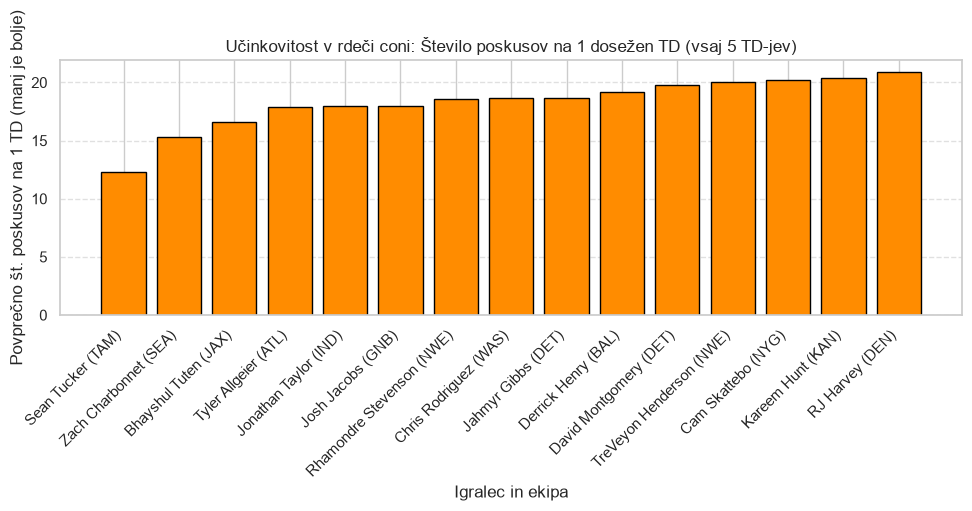

In [89]:
# Izločimo tiste z manj kot 5 touchdowni
rb_td = df[(df["pozicija"] == "RB") & (df["rushing_td"] >= 5)].copy()
rb_td["poskusov_na_td"] = rb_td["rushing_att"] / rb_td["rushing_td"]

# Top igralci z najmanj poskusi na 1 TD (ob pogoju vsaj 5 TD-jev)
top_td_stroj = rb_td.sort_values(by="poskusov_na_td", ascending=True).head(15)

plt.figure(figsize=(10, 5))
plt.bar(top_td_stroj["igralec"] + " (" + top_td_stroj["ekipa"] + ")", top_td_stroj["poskusov_na_td"], color="darkorange", edgecolor="black")
plt.title("Učinkovitost v rdeči coni: Število poskusov na 1 dosežen TD (vsaj 5 TD-jev)")
plt.xlabel("Igralec in ekipa")
plt.ylabel("Povprečno št. poskusov na 1 TD (manj je bolje)")
plt.xticks(rotation=45, ha="right")
plt.grid(axis="y", linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()

Opazimo nekaj novih imen, ki ji ni bilo med najboljšimi tekači. To je zato, ker imajo ekipe specifične igralce, ki jih uporabijo samo v določenih situacijah. Sean Tucker največkrat dobi priložnost le takrat, ko mora ekipa pridobiti manj kot 5 jardov za touchdown ali nov prvi poksus. Na splošno pa se število tekov potrebnih za touchdown med najboljšimi tekači giblje med 15 in 20.